# DATA 612 – Project 3: Matrix Factorization with SVD

**Author:** Kevin Martin  
**Course:** DATA 612 – Recommender Systems  
**Program:** MS Data Science, CUNY School of Professional Studies  
**Date:** June 2026

## Introduction

For this project, I will implement a matrix factorization method using Singular Value Decomposition (SVD) in the context of a recommender system.

The goal is to show how a user-item ratings matrix can be reduced into a smaller set of hidden features, also called latent factors. These latent factors can then be used to reconstruct predicted ratings and generate recommendations.

I am using a small movie and television ratings dataset so that the SVD process is easier to understand, explain, and interpret.

In [7]:
import numpy as np
import pandas as pd

## Create a Larger Ratings Dataset

For this project, I created a synthetic movie ratings dataset using real movie titles. The dataset contains 50 users and 20 movies, which makes it larger than the small toy dataset used in Project 2.

Ratings range from 1 to 5, where higher values indicate stronger user preference. Missing values represent movies that a user has not rated. This allows the project to demonstrate how SVD can be used to reconstruct missing ratings and support recommendations.

This dataset is still simplified for learning purposes, but it is large enough to demonstrate the matrix factorization process more clearly than the earlier toy example.

In [8]:
np.random.seed(42)

num_users = 50

movie_titles = [
    "The Shawshank Redemption",
    "The Godfather",
    "The Dark Knight",
    "Pulp Fiction",
    "Forrest Gump",
    "Inception",
    "The Matrix",
    "Titanic",
    "Gladiator",
    "Jurassic Park",
    "Toy Story",
    "The Lion King",
    "Black Panther",
    "Avatar",
    "The Avengers",
    "Interstellar",
    "The Silence of the Lambs",
    "Goodfellas",
    "The Social Network",
    "Get Out"
]

ratings_matrix = pd.DataFrame(
    np.random.choice(
        [1, 2, 3, 4, 5, np.nan],
        size=(num_users, len(movie_titles)),
        p=[0.12, 0.15, 0.20, 0.20, 0.18, 0.15]
    ),
    index=[f"User_{i}" for i in range(1, num_users + 1)],
    columns=movie_titles
)

ratings_matrix.head()

,The Shawshank Redemption,The Godfather,The Dark Knight,Pulp Fiction,Forrest Gump,Inception,The Matrix,Titanic,Gladiator,Jurassic Park,Toy Story,The Lion King,Black Panther,Avatar,The Avengers,Interstellar,The Silence of the Lambs,Goodfellas,The Social Network,Get Out
User_1,3.0,NaN,5.0,4.0,2.0,2.0,1.0,NaN,4.0,5.0,1.0,NaN,5.0,2.0,2.0,2.0,3.0,4.0,3.0,3.0
User_2,4.0,2.0,3.0,3.0,3.0,5.0,2.0,4.0,4.0,1.0,4.0,2.0,1.0,NaN,NaN,5.0,3.0,1.0,5.0,3.0
User_3,2.0,4.0,1.0,NaN,2.0,4.0,3.0,4.0,4.0,2.0,NaN,5.0,NaN,NaN,4.0,NaN,1.0,2.0,1.0,3.0
User_4,3.0,3.0,5.0,3.0,3.0,4.0,2.0,5.0,1.0,NaN,5.0,2.0,1.0,5.0,5.0,5.0,5.0,1.0,3.0,1.0
User_5,NaN,4.0,3.0,1.0,3.0,3.0,5.0,4.0,NaN,4.0,1.0,5.0,5.0,4.0,5.0,4.0,4.0,3.0,1.0,1.0


## Check Missing Ratings

The ratings matrix contains missing values because not every user has rated every movie. These missing values represent unrated movies.

Before applying SVD, it is important to understand how much missing data exists because SVD requires a complete numeric matrix with no missing values.

In [11]:
missing_count = ratings_matrix.isna().sum().sum()
total_cells = ratings_matrix.size
missing_percent = missing_count / total_cells * 100

print("Total ratings matrix cells:", total_cells)
print("Missing ratings:", missing_count)
print("Percent missing:", round(missing_percent, 2), "%")

Total ratings matrix cells: 1000
Missing ratings: 153
Percent missing: 15.3 %


## Handle Missing Values

SVD requires a complete matrix with no missing values. Instead of replacing missing ratings with zeros, missing values will be filled using the average rating for each movie.

This approach is more realistic because an unrated movie does not necessarily mean the user disliked the movie. Using the movie average helps reduce bias introduced by treating missing values as zero ratings.

In [12]:
movie_means = ratings_matrix.mean()

ratings_filled = ratings_matrix.fillna(movie_means)

ratings_filled.head()

,The Shawshank Redemption,The Godfather,The Dark Knight,Pulp Fiction,Forrest Gump,Inception,The Matrix,Titanic,Gladiator,Jurassic Park,Toy Story,The Lion King,Black Panther,Avatar,The Avengers,Interstellar,The Silence of the Lambs,Goodfellas,The Social Network,Get Out
User_1,3.000000,3.261905,5.0,4.000000,2.0,2.0,1.0,3.5,4.00,5.000000,1.0,3.578947,5.000000,2.00,2.000000,2.000000,3.0,4.0,3.0,3.0
User_2,4.000000,2.000000,3.0,3.000000,3.0,5.0,2.0,4.0,4.00,1.000000,4.0,2.000000,1.000000,3.25,2.809524,5.000000,3.0,1.0,5.0,3.0
User_3,2.000000,4.000000,1.0,3.311111,2.0,4.0,3.0,4.0,4.00,2.000000,3.0,5.000000,3.073171,3.25,4.000000,3.128205,1.0,2.0,1.0,3.0
User_4,3.000000,3.000000,5.0,3.000000,3.0,4.0,2.0,5.0,1.00,3.069767,5.0,2.000000,1.000000,5.00,5.000000,5.000000,5.0,1.0,3.0,1.0
User_5,3.069767,4.000000,3.0,1.000000,3.0,3.0,5.0,4.0,2.85,4.000000,1.0,5.000000,5.000000,4.00,5.000000,4.000000,4.0,3.0,1.0,1.0


### Interpretation

The original ratings matrix contained missing values (NaN), which represent movies that users did not rate. A missing rating does not necessarily mean that a user disliked a movie. It may simply indicate that the user never watched the movie or chose not to provide a rating.

Because SVD requires a complete numeric matrix, the missing values had to be replaced with estimated values. One common approach is to replace missing ratings with zeros; however, this can introduce bias because a zero may incorrectly suggest that a user strongly disliked a movie.

Instead, missing ratings were replaced with the average rating for each movie. Because movie averages may contain decimal values, the resulting matrix is stored as floating-point numbers. This is why some ratings appear as values such as 4.000000 while others appear as values such as 3.261905. This approach assumes a typical rating rather than a negative rating and provides a reasonable estimate while allowing SVD to operate on a complete matrix. Although movie averages may not perfectly represent an individual user's preference, they are generally less biased than treating all missing ratings as zeros.

This approach represents a compromise between leaving ratings missing, which SVD cannot process, and assigning ratings that may unfairly influence the recommendation process.


## Apply Singular Value Decomposition (SVD)

Singular Value Decomposition (SVD) is a matrix factorization technique used to reduce a large ratings matrix into a smaller set of hidden features, also known as latent factors.

Rather than comparing users directly to other users or movies directly to other movies, SVD identifies underlying patterns within the ratings data. These latent factors can then be used to reconstruct missing ratings and generate recommendations.

For this project, Truncated SVD will be used to reduce the ratings matrix into five latent factors.

In [13]:
svd = TruncatedSVD(n_components=5, random_state=42)

user_factors = svd.fit_transform(ratings_filled)

item_factors = svd.components_

print("User Factors Shape:", user_factors.shape)
print("Item Factors Shape:", item_factors.shape)

User Factors Shape: (50, 5)
Item Factors Shape: (5, 20)


### Interpretation

The original ratings matrix contained 50 users and 20 movies. After applying Truncated SVD with five components, the ratings data was reduced to five latent factors.

The user factors matrix has a shape of (50, 5), meaning each user is now represented by five hidden preference dimensions instead of twenty individual movie ratings.

The item factors matrix has a shape of (5, 20), meaning each movie is represented by its relationship to the same five latent factors.

This dimensionality reduction simplifies the ratings matrix while preserving the most important patterns in the data. These latent factors can then be used to reconstruct ratings and generate recommendations.

## Reconstruct the Ratings Matrix

After SVD identifies the latent factors within the ratings data, the user factors and item factors can be multiplied together to reconstruct the ratings matrix.

The reconstructed matrix contains ratings predicted from the latent factors discovered by the SVD model. These predicted ratings can be used to estimate missing values and support recommendation generation.

In [14]:
reconstructed_matrix = np.dot(user_factors, item_factors)

reconstructed_df = pd.DataFrame(
    reconstructed_matrix,
    index=ratings_filled.index,
    columns=ratings_filled.columns
)

reconstructed_df.head()

,The Shawshank Redemption,The Godfather,The Dark Knight,Pulp Fiction,Forrest Gump,Inception,The Matrix,Titanic,Gladiator,Jurassic Park,Toy Story,The Lion King,Black Panther,Avatar,The Avengers,Interstellar,The Silence of the Lambs,Goodfellas,The Social Network,Get Out
User_1,2.740715,2.887812,2.686994,3.293978,1.840026,3.058514,3.111193,3.314555,3.491811,3.665823,1.515809,3.898358,3.136589,2.812148,2.588068,2.684971,2.508473,3.782065,3.992638,4.072330
User_2,3.293097,3.077431,3.956767,4.494551,3.315756,3.572587,2.129217,3.751540,2.829320,1.262214,2.878173,2.982710,1.474563,3.631519,2.815627,4.132891,3.392338,2.571557,2.854127,2.490535
User_3,2.026766,4.254032,2.021289,3.363062,3.360488,3.165570,2.443730,3.126114,3.609147,2.798664,2.790059,4.239509,3.064832,3.011141,2.320605,3.106501,1.385846,2.359864,3.160968,2.218945
User_4,2.997806,3.037922,4.498977,4.156395,4.503198,3.157952,2.727781,4.045298,1.616124,1.668622,4.778639,1.796943,1.765946,4.701258,4.048721,4.165824,5.543720,1.281293,2.269411,2.444849
User_5,3.093640,3.667735,2.207585,2.614800,3.408074,3.080202,3.793920,3.495609,2.598584,4.059811,3.986886,3.893328,4.186791,3.292888,2.990028,2.720517,3.533219,3.005525,3.249673,2.945301


### Interpretation

The reconstructed matrix contains ratings predicted by the SVD model. Unlike the original ratings matrix, the reconstructed values are estimates generated from the five latent factors identified during matrix factorization.

Most predicted ratings remain within the original rating scale of 1 to 5, suggesting that the reduced representation preserved the major patterns in the data. This demonstrates how SVD can compress a large ratings matrix into a smaller number of hidden factors while still maintaining useful information about user preferences.

The reconstructed ratings can be used to estimate missing values and support recommendation generation.


## Evaluate Reconstruction Accuracy

To evaluate how well the SVD model reconstructed the ratings matrix, Mean Absolute Error (MAE) will be calculated.

MAE measures the average difference between the original ratings and the ratings predicted by the model. Lower MAE values indicate that the reconstructed ratings are closer to the original ratings.

In [15]:
mae = mean_absolute_error(
    ratings_filled.values.flatten(),
    reconstructed_df.values.flatten()
)

print("Mean Absolute Error (MAE):", round(mae, 4))

Mean Absolute Error (MAE): 0.7243


### Interpretation

The SVD model produced a Mean Absolute Error (MAE) of 0.7243. This means that, on average, the reconstructed ratings differ from the original ratings by approximately 0.72 rating points.

Considering that ratings are measured on a scale from 1 to 5, an average error of less than one rating point suggests that the model was able to preserve many of the important rating patterns present in the original dataset.

Although the reconstructed ratings are not exact matches to the original ratings, the relatively low MAE indicates that the latent factors captured meaningful information about user preferences and movie characteristics.


## Generate Recommendations

The reconstructed ratings matrix can be used to identify movies with the highest predicted ratings for a user.

For demonstration purposes, recommendations will be generated for User_1 by selecting the movies with the highest predicted ratings from the reconstructed matrix.

In [16]:
user_recommendations = reconstructed_df.loc["User_1"]

top_recommendations = user_recommendations.sort_values(
    ascending=False
).head(5)

print(top_recommendations)

Get Out               4.072330
The Social Network    3.992638
The Lion King         3.898358
Goodfellas            3.782065
Jurassic Park         3.665823
Name: User_1, dtype: float64


### Interpretation

The reconstructed ratings matrix was used to identify the movies with the highest predicted ratings for User_1. These recommendations are based on the latent factors discovered by the SVD model rather than direct user-to-user or item-to-item comparisons.

The results suggest that Get Out, The Social Network, The Lion King, Goodfellas, and Jurassic Park are the movies most likely to receive high ratings from User_1 based on the rating patterns learned by the model.

These recommendations demonstrate how matrix factorization can be used to estimate user preferences and recommend items even when explicit ratings are missing.


## Visualizing Recommendations

The top recommended movies for User_1 are displayed below. Higher predicted ratings indicate movies that the SVD model believes the user is more likely to enjoy based on the latent factors identified during matrix factorization.

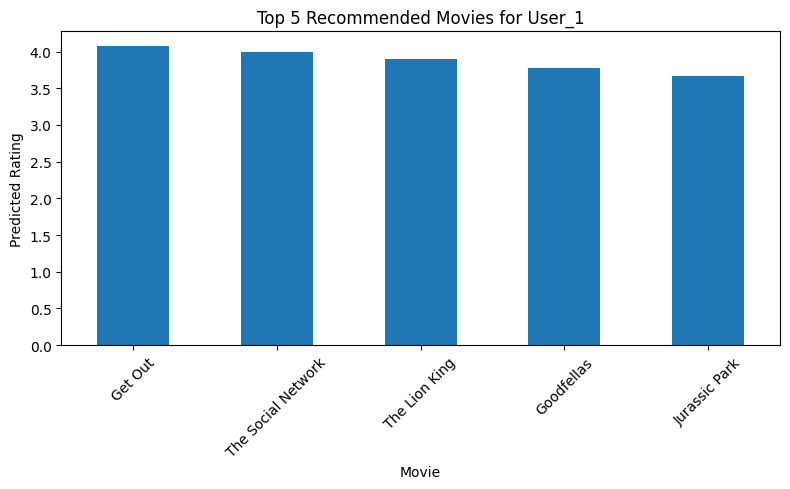

In [17]:
top_recommendations.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Top 5 Recommended Movies for User_1")
plt.ylabel("Predicted Rating")
plt.xlabel("Movie")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Limitations

Several limitations should be considered when interpreting these results.

First, the dataset used in this project was synthetically generated rather than collected from real users. While real movie titles were used, the ratings themselves were randomly generated for educational purposes.

Second, missing ratings were replaced using movie averages. Although this approach is generally less biased than replacing missing values with zeros, the average rating may not accurately reflect an individual user's true preference.

Third, recommendations were generated from the reconstructed matrix without removing movies that users may have already rated. In a production recommender system, previously rated items would typically be excluded from recommendation lists.

Finally, only five latent factors were used in the SVD model. Different numbers of latent factors could produce different recommendation results and reconstruction accuracy.


## Conclusion

This project demonstrated how Singular Value Decomposition (SVD) can be used as a matrix factorization technique within a recommender system.

Beginning with a movie ratings matrix containing 50 users and 20 movies, missing values were handled using movie averages, and Truncated SVD was applied to identify five latent factors representing hidden rating patterns. These latent factors were then used to reconstruct the ratings matrix and generate predicted ratings.

The reconstructed matrix achieved a Mean Absolute Error (MAE) of 0.7243, indicating that the model was able to preserve many of the important patterns present in the original data. Using the reconstructed ratings, movie recommendations were generated for a sample user.

Overall, this project demonstrated how matrix factorization can reduce the dimensionality of a ratings matrix while still providing meaningful recommendations based on learned user preference patterns. Compared to earlier collaborative filtering approaches, this project also incorporated a larger dataset, an evaluation metric (MAE), and a more thoughtful approach to handling missing values. These additions provided a more realistic demonstration of how recommender systems can be developed and evaluated using matrix factorization techniques.

